# Non-Parametric Hypothesis Testing
## Wilcoxon, Mann-Whitney U, Kruskal-Wallis, and Friedman

### Why Non-Parametric?

Parametric tests (t-tests, ANOVA) assume:
- **Normality** of the sampling distribution
- **Homogeneity of variance** across groups
- Data measured on an **interval or ratio scale**

When these assumptions are violated — especially with **small samples**, **skewed distributions**, **outliers**, or **ordinal data** — non-parametric tests provide valid alternatives.

### Key Principle

Non-parametric tests work with **ranks** rather than raw values. They ask:
> *"Do the groups differ in their central tendency?"*

instead of:
> *"Do the groups differ in their means?"*

### Trade-offs

| Aspect | Parametric | Non-Parametric |
|--------|-----------|----------------|
| Power | Higher (when assumptions met) | Lower (but more robust) |
| Assumptions | Strict | Minimal |
| Data type | Interval/Ratio | Ordinal, Interval, Ratio |
| Outliers | Sensitive | Robust |
| Effect size | Cohen's d, eta-squared | Rank-biserial r, epsilon-squared, Kendall's W |


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import scipy
import pandas as pd

np.random.seed(42)

print("Libraries loaded successfully!")
print(f"NumPy version: {np.__version__}")
print(f"SciPy version: {scipy.__version__}")


Libraries loaded successfully!
NumPy version: 2.4.3
SciPy version: 1.17.1


## 1. Ranks: The Foundation of Non-Parametric Tests

All major non-parametric tests transform raw data into **ranks** (1 = smallest, N = largest).

### Why Ranks?
- **Robust to outliers**: An extreme value gets the top rank, but its magnitude doesn't matter
- **Valid for ordinal data**: Only the order matters, not the distance between values
- **Distribution-free**: No assumption about the underlying distribution shape

### Example
Raw scores: [12, 15, 10, 20, 18]
Ranks:     [2,  3,  1,  5,  4]


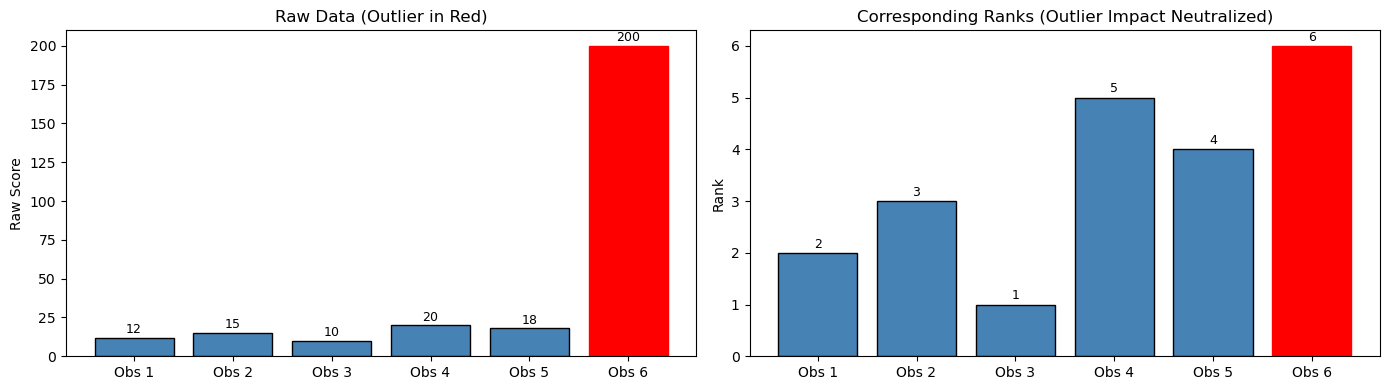

Raw scores: [ 12  15  10  20  18 200]
Ranks:      [2 3 1 5 4 6]

Notice: The outlier (200) gets rank 6, but its extreme magnitude is ignored.


In [2]:
np.random.seed(1)

# Demonstrate ranking
raw_scores = np.array([12, 15, 10, 20, 18, 200])  # 200 is an outlier
ranks = stats.rankdata(raw_scores)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Raw scores
ax1 = axes[0]
bars1 = ax1.bar(range(len(raw_scores)), raw_scores, color='steelblue', edgecolor='black')
bars1[-1].set_color('red')  # Highlight outlier
ax1.set_xticks(range(len(raw_scores)))
ax1.set_xticklabels([f'Obs {i+1}' for i in range(len(raw_scores))])
ax1.set_ylabel('Raw Score')
ax1.set_title('Raw Data (Outlier in Red)')

# Ranks
ax2 = axes[1]
bars2 = ax2.bar(range(len(ranks)), ranks, color='steelblue', edgecolor='black')
bars2[-1].set_color('red')
ax2.set_xticks(range(len(ranks)))
ax2.set_xticklabels([f'Obs {i+1}' for i in range(len(ranks))])
ax2.set_ylabel('Rank')
ax2.set_title('Corresponding Ranks (Outlier Impact Neutralized)')

# Add value labels
for i, (v, r) in enumerate(zip(raw_scores, ranks)):
    ax1.text(i, v + 3, str(v), ha='center', fontsize=9)
    ax2.text(i, r + 0.1, str(int(r)), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('ranking_demonstration.png', dpi=150, bbox_inches='tight')
plt.show()

print("Raw scores:", raw_scores)
print("Ranks:     ", ranks.astype(int))
print("\nNotice: The outlier (200) gets rank 6, but its extreme magnitude is ignored.")


## 2. Mann-Whitney U Test

**Use when**: Comparing two **independent** groups with non-normal data or outliers.

**Null hypothesis**: The two groups come from the same distribution (same median/location).

**Alternative hypothesis**: One group tends to have larger values than the other.

### The U Statistic

U counts the number of times observations in one group exceed observations in the other group. Under H0, U should be about n1*n2/2.

### Effect Size: Rank-Biserial Correlation

$$r_{rb} = \frac{2U}{n_1 n_2} - 1$$

Ranges from -1 to +1. Also report the **probability of superiority**: P(X > Y).


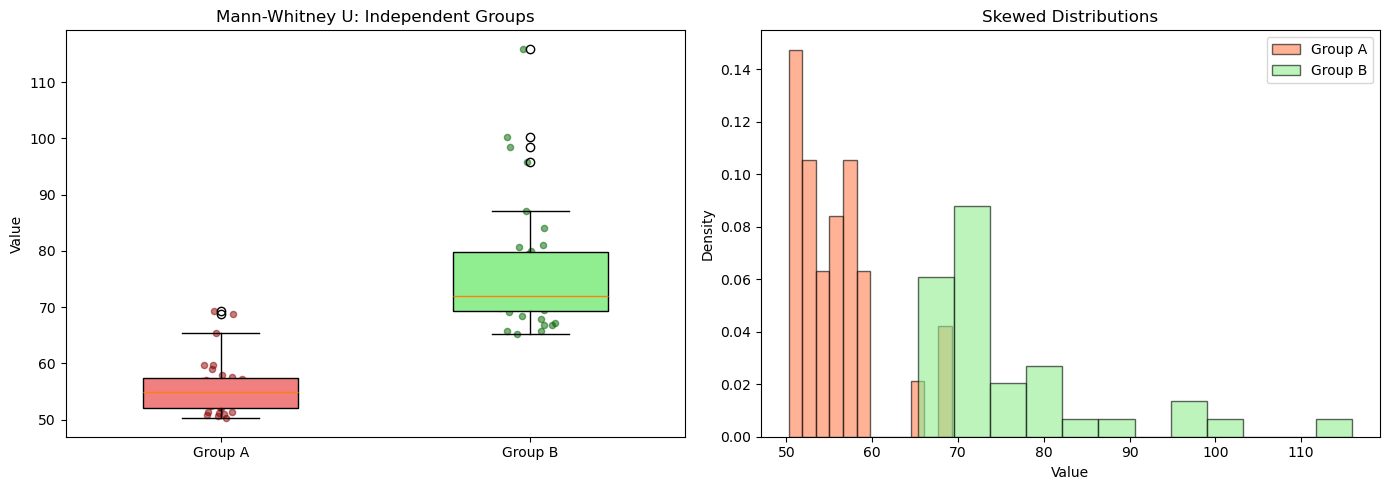

Mann-Whitney U: 18.00
p-value: 0.0000
Rank-biserial r: -0.9657
Probability of superiority: 0.0171
Z approximation: -6.6716
Decision: Reject H0


In [3]:
np.random.seed(2)

# Skewed, independent data
group_a = stats.expon.rvs(scale=10, size=30) + 50
group_b = stats.expon.rvs(scale=10, size=35) + 65

# Mann-Whitney U test
u_stat, p_mw = stats.mannwhitneyu(group_a, group_b, alternative='two-sided')

# Effect sizes
n1, n2 = len(group_a), len(group_b)
# Rank-biserial correlation
r_rb = (2 * u_stat) / (n1 * n2) - 1
# Probability of superiority
prob_sup = u_stat / (n1 * n2)

# Z approximation for additional context
mu_u = n1 * n2 / 2
sigma_u = np.sqrt(n1 * n2 * (n1 + n2 + 1) / 12)
z_mw = (u_stat - mu_u) / sigma_u

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplots
ax1 = axes[0]
bp = ax1.boxplot([group_a, group_b], tick_labels=['Group A', 'Group B'],
                  patch_artist=True, widths=0.5)
bp['boxes'][0].set_facecolor('lightcoral')
bp['boxes'][1].set_facecolor('lightgreen')

np.random.seed(3)
j1 = np.random.normal(1, 0.04, len(group_a))
j2 = np.random.normal(2, 0.04, len(group_b))
ax1.scatter(j1, group_a, alpha=0.5, s=20, color='darkred')
ax1.scatter(j2, group_b, alpha=0.5, s=20, color='darkgreen')
ax1.set_ylabel('Value')
ax1.set_title('Mann-Whitney U: Independent Groups')

# Histograms
ax2 = axes[1]
ax2.hist(group_a, bins=12, density=True, alpha=0.6, color='coral', edgecolor='black', label='Group A')
ax2.hist(group_b, bins=12, density=True, alpha=0.6, color='lightgreen', edgecolor='black', label='Group B')
ax2.set_xlabel('Value')
ax2.set_ylabel('Density')
ax2.set_title('Skewed Distributions')
ax2.legend()

plt.tight_layout()
plt.savefig('mann_whitney_u.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Mann-Whitney U: {u_stat:.2f}")
print(f"p-value: {p_mw:.4f}")
print(f"Rank-biserial r: {r_rb:.4f}")
print(f"Probability of superiority: {prob_sup:.4f}")
print(f"Z approximation: {z_mw:.4f}")
print(f"Decision: {'Reject H0' if p_mw < 0.05 else 'Fail to reject H0'}")


## 3. Wilcoxon Signed-Rank Test

**Use when**: Comparing two **paired** (related) measurements on non-normal data.

**Null hypothesis**: The median of the differences is zero.

### How it works
1. Compute differences (After - Before)
2. Remove zero differences
3. Rank the absolute differences
4. Sum ranks for positive and negative differences separately
5. The test statistic is the smaller of the two rank sums

### Effect Size

**Rank-biserial correlation** for paired data:
$$r_{rb} = \frac{R_{positive} - R_{negative}}{N(N+1)/2}$$

where N is the number of non-zero differences.


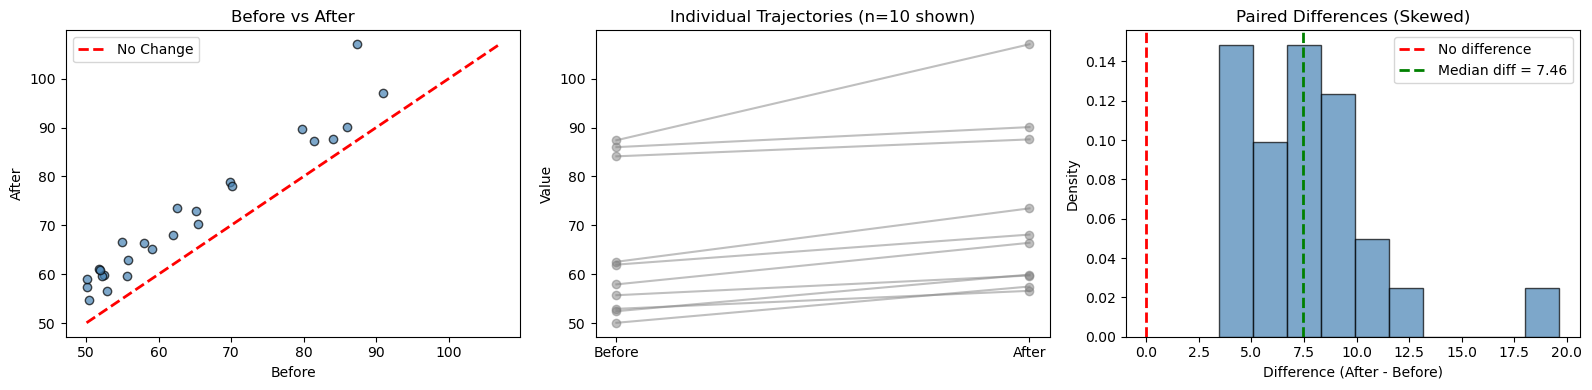

Wilcoxon statistic: 0.00
p-value: 0.0000
Rank-biserial r: 1.0000
Median difference: 7.4591
Decision: Reject H0


In [4]:
np.random.seed(4)

n = 25
before = stats.expon.rvs(scale=10, size=n) + 50
after = before + stats.expon.rvs(scale=6, size=n) + 3  # Paired, skewed differences

# Wilcoxon signed-rank test
w_stat, p_wilcoxon = stats.wilcoxon(before, after, alternative='two-sided')

# Manual rank-biserial effect size
diff = after - before
diff_nz = diff[diff != 0]
ranks = stats.rankdata(np.abs(diff_nz))
pos_sum = np.sum(ranks[diff_nz > 0])
neg_sum = np.sum(ranks[diff_nz < 0])
N_eff = len(diff_nz)
r_rb_w = (pos_sum - neg_sum) / (N_eff * (N_eff + 1) / 2)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Scatter
ax1 = axes[0]
ax1.scatter(before, after, alpha=0.7, color='steelblue', edgecolors='black')
min_val = min(before.min(), after.min())
max_val = max(before.max(), after.max())
ax1.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='No Change')
ax1.set_xlabel('Before')
ax1.set_ylabel('After')
ax1.set_title('Before vs After')
ax1.legend()

# Trajectories (first 10)
ax2 = axes[1]
for i in range(min(10, n)):
    ax2.plot([0, 1], [before[i], after[i]], 'o-', color='gray', alpha=0.5)
ax2.set_xticks([0, 1])
ax2.set_xticklabels(['Before', 'After'])
ax2.set_ylabel('Value')
ax2.set_title(f'Individual Trajectories (n={min(10,n)} shown)')

# Differences
ax3 = axes[2]
ax3.hist(diff, bins=10, density=True, alpha=0.7, color='steelblue', edgecolor='black')
ax3.axvline(0, color='red', linestyle='--', lw=2, label='No difference')
ax3.axvline(np.median(diff), color='green', linestyle='--', lw=2,
            label=rf'Median diff = {np.median(diff):.2f}')
ax3.set_xlabel('Difference (After - Before)')
ax3.set_ylabel('Density')
ax3.set_title('Paired Differences (Skewed)')
ax3.legend()

plt.tight_layout()
plt.savefig('wilcoxon_signed_rank.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Wilcoxon statistic: {w_stat:.2f}")
print(f"p-value: {p_wilcoxon:.4f}")
print(f"Rank-biserial r: {r_rb_w:.4f}")
print(f"Median difference: {np.median(diff):.4f}")
print(f"Decision: {'Reject H0' if p_wilcoxon < 0.05 else 'Fail to reject H0'}")


## 4. Kruskal-Wallis H Test

**Use when**: Comparing **three or more independent groups** with non-normal data.

**Non-parametric alternative to**: One-way ANOVA.

### The H Statistic

Based on the ranks of all observations pooled across groups:

$$H = \frac{12}{N(N+1)} \sum_{i=1}^{k} \frac{R_i^2}{n_i} - 3(N+1)$$

where $R_i$ is the sum of ranks for group $i$, $n_i$ is the group size, and $N$ is the total sample size.

Under H0, H follows a chi-squared distribution with $k-1$ degrees of freedom.

### Effect Size: Epsilon-Squared

$$\epsilon^2 = \frac{H}{N - 1}$$

| $\epsilon^2$ | Interpretation |
|-------------|----------------|
| 0.01 | Small |
| 0.06 | Medium |
| 0.14 | Large |


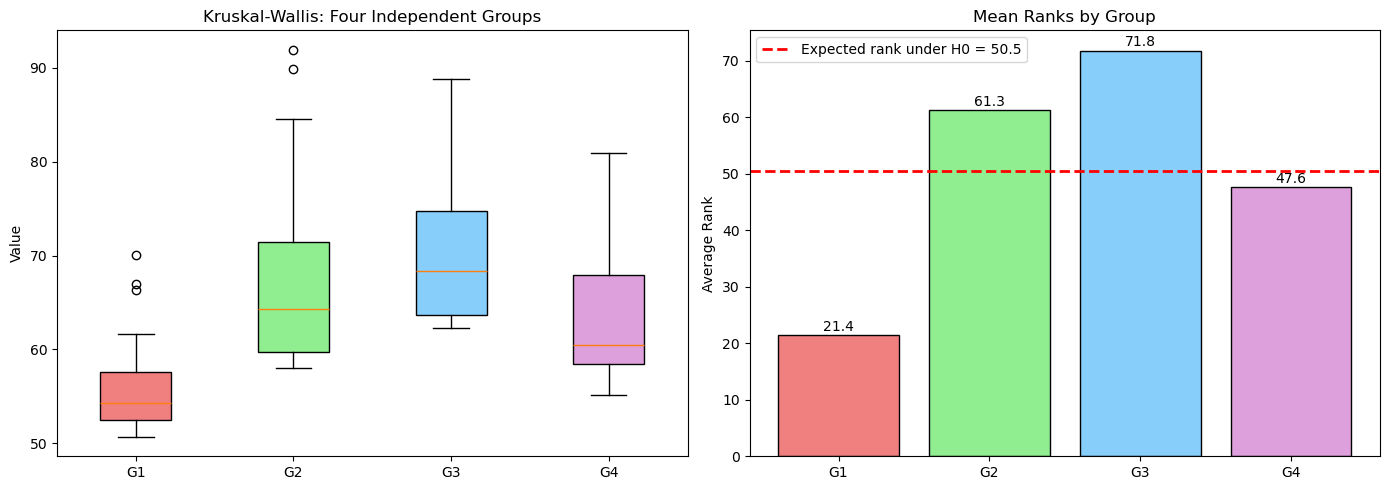

Kruskal-Wallis H: 42.2866
p-value: 0.0000
Epsilon-squared: 0.4271
Mean ranks by group:
group
G1    21.40
G2    61.28
G3    71.76
G4    47.56
Name: rank, dtype: float64
Decision: Reject H0


In [5]:
np.random.seed(5)

# Four skewed groups
g1 = stats.expon.rvs(scale=8, size=25) + 50
g2 = stats.expon.rvs(scale=8, size=25) + 58
g3 = stats.expon.rvs(scale=8, size=25) + 62
g4 = stats.expon.rvs(scale=8, size=25) + 55

# Kruskal-Wallis test
h_stat, p_kw = stats.kruskal(g1, g2, g3, g4)

# Effect size
n_total = len(g1) + len(g2) + len(g3) + len(g4)
epsilon_sq = h_stat / (n_total - 1)

# Average ranks per group (for visualization)
all_data = np.concatenate([g1, g2, g3, g4])
all_labels = (['G1']*len(g1) + ['G2']*len(g2) + ['G3']*len(g3) + ['G4']*len(g4))
ranks = stats.rankdata(all_data)

df_ranks = pd.DataFrame({'group': all_labels, 'rank': ranks})
avg_ranks = df_ranks.groupby('group')['rank'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplots
ax1 = axes[0]
bp = ax1.boxplot([g1, g2, g3, g4], tick_labels=['G1', 'G2', 'G3', 'G4'],
                  patch_artist=True)
colors = ['lightcoral', 'lightgreen', 'lightskyblue', 'plum']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
ax1.set_ylabel('Value')
ax1.set_title('Kruskal-Wallis: Four Independent Groups')

# Average ranks
ax2 = axes[1]
bars = ax2.bar(avg_ranks.index, avg_ranks.values, color=colors, edgecolor='black')
ax2.axhline((n_total + 1) / 2, color='red', linestyle='--', lw=2,
            label=rf'Expected rank under H0 = {(n_total+1)/2:.1f}')
ax2.set_ylabel('Average Rank')
ax2.set_title('Mean Ranks by Group')
ax2.legend()

for bar in bars:
    h = bar.get_height()
    ax2.annotate(f'{h:.1f}', xy=(bar.get_x() + bar.get_width()/2, h),
                 xytext=(0, 3), textcoords='offset points', ha='center')

plt.tight_layout()
plt.savefig('kruskal_wallis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Kruskal-Wallis H: {h_stat:.4f}")
print(f"p-value: {p_kw:.4f}")
print(f"Epsilon-squared: {epsilon_sq:.4f}")
print("Mean ranks by group:")
print(avg_ranks)
print(f"Decision: {'Reject H0' if p_kw < 0.05 else 'Fail to reject H0'}")


## 5. Post-Hoc Analysis: Dunn's Test with Bonferroni Correction

Kruskal-Wallis tells us **that** groups differ, but not **which** pairs differ.

### Dunn's Test

A rank-based post-hoc test comparing all pairs of groups:

$$z = \frac{\bar{R}_i - \bar{R}_j}{\sqrt{\frac{N(N+1)}{12} \cdot C \cdot \left(\frac{1}{n_i} + \frac{1}{n_j}\right)}}$$

where $C$ is a tie correction factor.

### Bonferroni Correction

With $m$ comparisons, multiply each p-value by $m$:

$$p_{adj} = \min(p \times m, 1.0)$$

This controls the **family-wise error rate**.


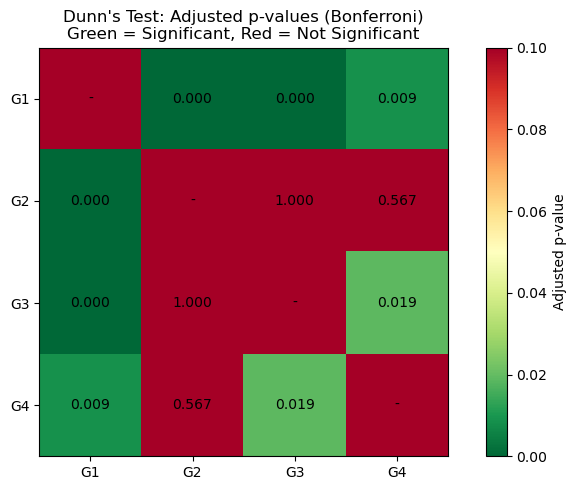

group1 group2  mean_rank_diff         z            p        p_adj  significant
    G1     G2          -39.88 -4.860043 1.173604e-06 7.041623e-06         True
    G1     G3          -50.36 -6.137205 8.398573e-10 5.039144e-09         True
    G1     G4          -26.16 -3.188032 1.432446e-03 8.594679e-03         True
    G2     G3          -10.48 -1.277163 2.015448e-01 1.000000e+00        False
    G2     G4           13.72  1.672011 9.452221e-02 5.671333e-01        False
    G3     G4           24.20  2.949173 3.186251e-03 1.911751e-02         True


In [6]:
def dunn_test(groups, group_names, alpha=0.05):
    """Manual implementation of Dunn's test with Bonferroni correction."""
    all_data = np.concatenate(groups)
    all_labels = np.concatenate([[name]*len(g) for name, g in zip(group_names, groups)])
    
    # Rank all data
    ranks = stats.rankdata(all_data)
    df = pd.DataFrame({'group': all_labels, 'rank': ranks})
    
    # Average ranks and sample sizes
    avg_ranks = df.groupby('group')['rank'].mean()
    ns = df.groupby('group').size()
    n_total = len(all_data)
    
    # Tie correction
    unique, counts = np.unique(all_data, return_counts=True)
    tie_counts = counts[counts > 1]
    tie_correction = 1 - np.sum(tie_counts**3 - tie_counts) / (n_total**3 - n_total)
    
    # Pairwise comparisons
    results = []
    n_groups = len(group_names)
    n_comparisons = n_groups * (n_groups - 1) // 2
    
    for i in range(n_groups):
        for j in range(i + 1, n_groups):
            ni, nj = ns.iloc[i], ns.iloc[j]
            ri, rj = avg_ranks.iloc[i], avg_ranks.iloc[j]
            
            se = np.sqrt((n_total * (n_total + 1) / 12) * tie_correction * (1/ni + 1/nj))
            z = (ri - rj) / se
            p = 2 * (1 - stats.norm.cdf(abs(z)))
            p_adj = min(p * n_comparisons, 1.0)
            
            results.append({
                'group1': group_names[i],
                'group2': group_names[j],
                'mean_rank_diff': ri - rj,
                'z': z,
                'p': p,
                'p_adj': p_adj,
                'significant': p_adj < alpha
            })
    
    return pd.DataFrame(results)

# Run Dunn's test on the Kruskal-Wallis data
group_names = ['G1', 'G2', 'G3', 'G4']
dunn_results = dunn_test([g1, g2, g3, g4], group_names)

fig, ax = plt.subplots(figsize=(8, 5))

# Heatmap of adjusted p-values
p_matrix = np.ones((4, 4))
for _, row in dunn_results.iterrows():
    i = group_names.index(row['group1'])
    j = group_names.index(row['group2'])
    p_matrix[i, j] = row['p_adj']
    p_matrix[j, i] = row['p_adj']

im = ax.imshow(p_matrix, cmap='RdYlGn_r', vmin=0, vmax=0.1)
ax.set_xticks(range(4))
ax.set_yticks(range(4))
ax.set_xticklabels(group_names)
ax.set_yticklabels(group_names)
ax.set_title("Dunn's Test: Adjusted p-values (Bonferroni)\nGreen = Significant, Red = Not Significant")

# Add text annotations
for i in range(4):
    for j in range(4):
        if i != j:
            ax.text(j, i, f'{p_matrix[i,j]:.3f}', ha='center', va='center', fontsize=10)
        else:
            ax.text(j, i, '-', ha='center', va='center', fontsize=10)

plt.colorbar(im, ax=ax, label='Adjusted p-value')
plt.tight_layout()
plt.savefig('dunn_posthoc.png', dpi=150, bbox_inches='tight')
plt.show()

print(dunn_results.to_string(index=False))


## 6. Friedman Test

**Use when**: Comparing **three or more related/paired** conditions on non-normal data.

**Non-parametric alternative to**: Repeated-measures ANOVA.

### How it works
1. Rank each subject's scores across conditions (within-subject ranking)
2. Sum the ranks for each condition
3. Test whether rank sums differ significantly

### Effect Size: Kendall's Coefficient of Concordance (W)

$$W = \frac{\chi^2_F}{m(n-1)}$$

where $m$ = number of conditions, $n$ = number of subjects.

| W | Interpretation |
|---|----------------|
| 0.1 | Weak |
| 0.3 | Moderate |
| 0.5 | Strong |


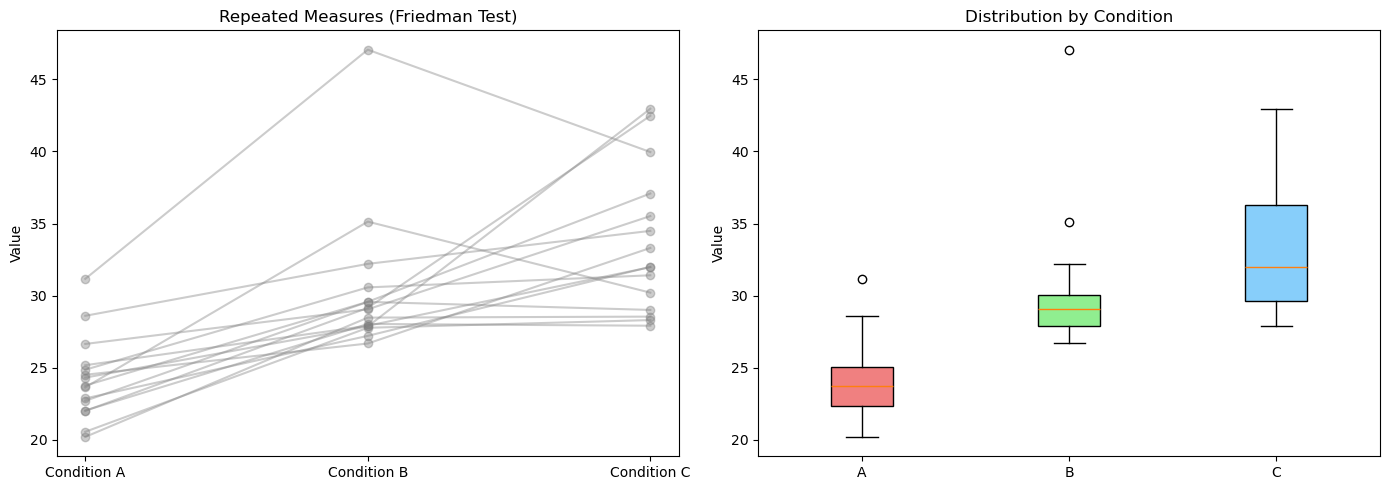

Friedman chi-square: 24.1333
p-value: 0.0000
Kendall's W: 0.5746
Decision: Reject H0


In [7]:
np.random.seed(6)

n_subjects = 15
# Three conditions with skewed data
cond_a = stats.expon.rvs(scale=5, size=n_subjects) + 20
cond_b = cond_a + stats.expon.rvs(scale=3, size=n_subjects) + 2
cond_c = cond_a + stats.expon.rvs(scale=3, size=n_subjects) + 5

# Friedman test
chi2_f, p_friedman = stats.friedmanchisquare(cond_a, cond_b, cond_c)

# Kendall's W
m = 3
n = n_subjects
kendall_w = chi2_f / (m * (n - 1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Connected trajectories
ax1 = axes[0]
for i in range(n_subjects):
    ax1.plot([0, 1, 2], [cond_a[i], cond_b[i], cond_c[i]], 'o-', color='gray', alpha=0.4)
ax1.set_xticks([0, 1, 2])
ax1.set_xticklabels(['Condition A', 'Condition B', 'Condition C'])
ax1.set_ylabel('Value')
ax1.set_title('Repeated Measures (Friedman Test)')

# Boxplot
ax2 = axes[1]
bp = ax2.boxplot([cond_a, cond_b, cond_c], tick_labels=['A', 'B', 'C'],
                  patch_artist=True)
colors = ['lightcoral', 'lightgreen', 'lightskyblue']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
ax2.set_ylabel('Value')
ax2.set_title('Distribution by Condition')

plt.tight_layout()
plt.savefig('friedman_test.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Friedman chi-square: {chi2_f:.4f}")
print(f"p-value: {p_friedman:.4f}")
print(f"Kendall's W: {kendall_w:.4f}")
print(f"Decision: {'Reject H0' if p_friedman < 0.05 else 'Fail to reject H0'}")


## 7. Effect Sizes for Non-Parametric Tests

Reporting effect sizes is essential — p-values alone don't tell you the magnitude of the effect.

| Test | Effect Size | Formula | Range |
|------|------------|---------|-------|
| Mann-Whitney U | Rank-biserial r | $(2U / n_1 n_2) - 1$ | -1 to +1 |
| Wilcoxon | Rank-biserial r | $(R_+ - R_-) / (N(N+1)/2)$ | -1 to +1 |
| Kruskal-Wallis | Epsilon-squared | $H / (N - 1)$ | 0 to 1 |
| Friedman | Kendall's W | $\chi^2_F / (m(n-1))$ | 0 to 1 |

### Interpretation Guidelines

**Rank-biserial r (Mann-Whitney & Wilcoxon):**
- 0.1 = small, 0.3 = medium, 0.5 = large

**Epsilon-squared (Kruskal-Wallis):**
- 0.01 = small, 0.06 = medium, 0.14 = large

**Kendall's W (Friedman):**
- 0.1 = weak, 0.3 = moderate, 0.5 = strong agreement
- 

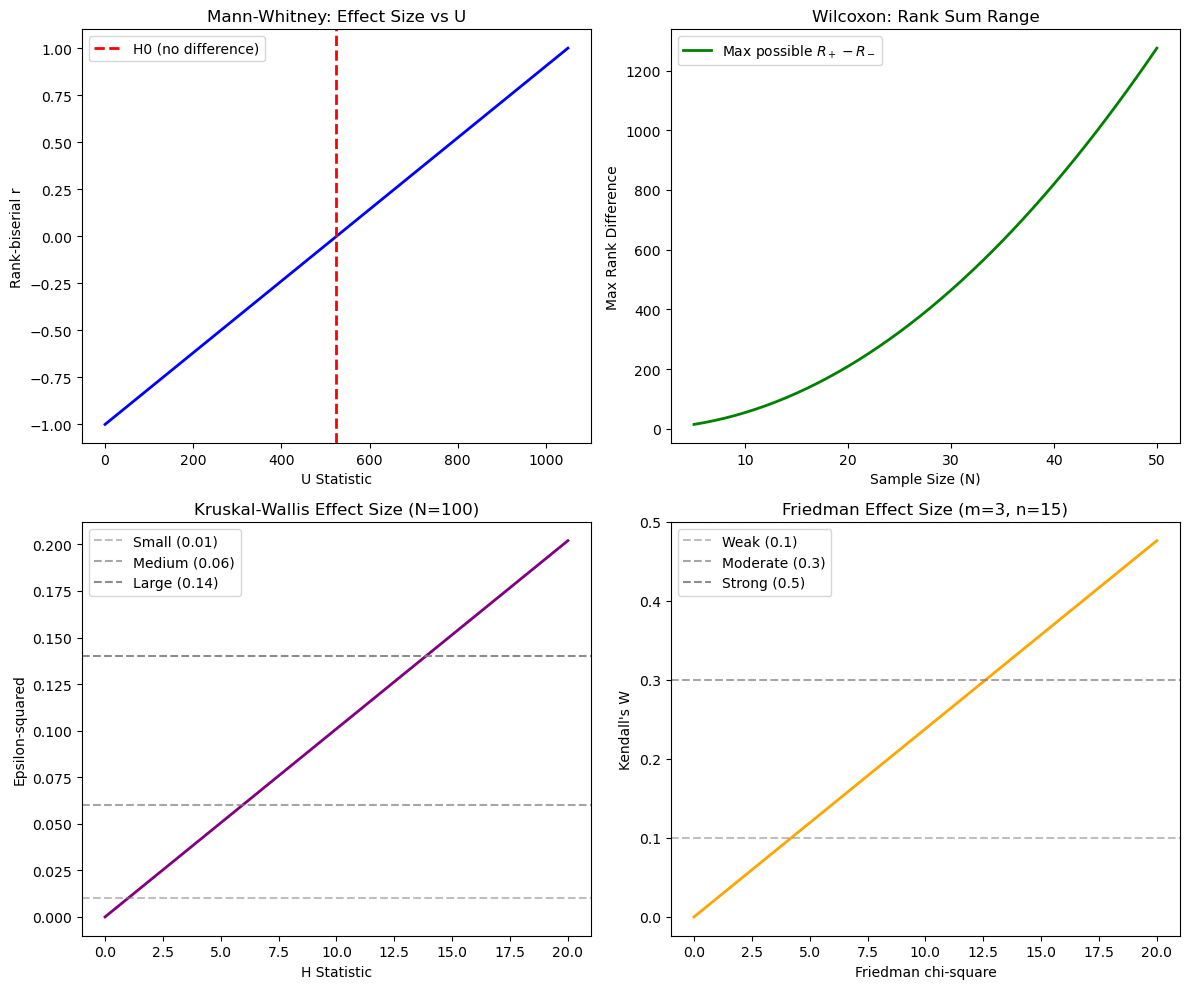

Effect size reference values displayed.


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Mann-Whitney effect size distribution
ax1 = axes[0, 0]
u_range = np.linspace(0, n1*n2, 1000)
r_range = (2 * u_range) / (n1 * n2) - 1
ax1.plot(u_range, r_range, 'b-', lw=2)
ax1.axvline(n1*n2/2, color='red', linestyle='--', lw=2, label='H0 (no difference)')
ax1.set_xlabel('U Statistic')
ax1.set_ylabel('Rank-biserial r')
ax1.set_title("Mann-Whitney: Effect Size vs U")
ax1.legend()

# Wilcoxon effect size
ax2 = axes[0, 1]
N_range = np.arange(5, 51)
max_r_diff = N_range * (N_range + 1) / 2
ax2.plot(N_range, max_r_diff, 'g-', lw=2, label='Max possible $R_+ - R_-$')
ax2.set_xlabel('Sample Size (N)')
ax2.set_ylabel('Max Rank Difference')
ax2.set_title('Wilcoxon: Rank Sum Range')
ax2.legend()

# KW epsilon-squared
ax3 = axes[1, 0]
h_vals = np.linspace(0, 20, 100)
n_demo = 100
ax3.plot(h_vals, h_vals / (n_demo - 1), 'purple', lw=2)
ax3.axhline(0.01, color='gray', linestyle='--', alpha=0.5, label='Small (0.01)')
ax3.axhline(0.06, color='gray', linestyle='--', alpha=0.7, label='Medium (0.06)')
ax3.axhline(0.14, color='gray', linestyle='--', alpha=0.9, label='Large (0.14)')
ax3.set_xlabel('H Statistic')
ax3.set_ylabel('Epsilon-squared')
ax3.set_title(f'Kruskal-Wallis Effect Size (N={n_demo})')
ax3.legend(loc='upper left')

# Kendall's W
ax4 = axes[1, 1]
chi2_range = np.linspace(0, 20, 100)
m_demo, n_demo_f = 3, 15
w_range = chi2_range / (m_demo * (n_demo_f - 1))
ax4.plot(chi2_range, w_range, 'orange', lw=2)
ax4.axhline(0.1, color='gray', linestyle='--', alpha=0.5, label='Weak (0.1)')
ax4.axhline(0.3, color='gray', linestyle='--', alpha=0.7, label='Moderate (0.3)')
ax4.axhline(0.5, color='gray', linestyle='--', alpha=0.9, label='Strong (0.5)')
ax4.set_xlabel('Friedman chi-square')
ax4.set_ylabel("Kendall's W")
ax4.set_title(f'Friedman Effect Size (m={m_demo}, n={n_demo_f})')
ax4.legend(loc='upper left')

plt.tight_layout()
plt.savefig('nonparametric_effect_sizes.png', dpi=150, bbox_inches='tight')
plt.show()

print("Effect size reference values displayed.")


## 8. Robustness to Outliers: Parametric vs Non-Parametric

A single extreme outlier can completely distort a t-test but has minimal impact on rank-based tests.

### Demonstration
- Two groups with similar means
- Add one extreme outlier to Group A
- Compare t-test and Mann-Whitney U results

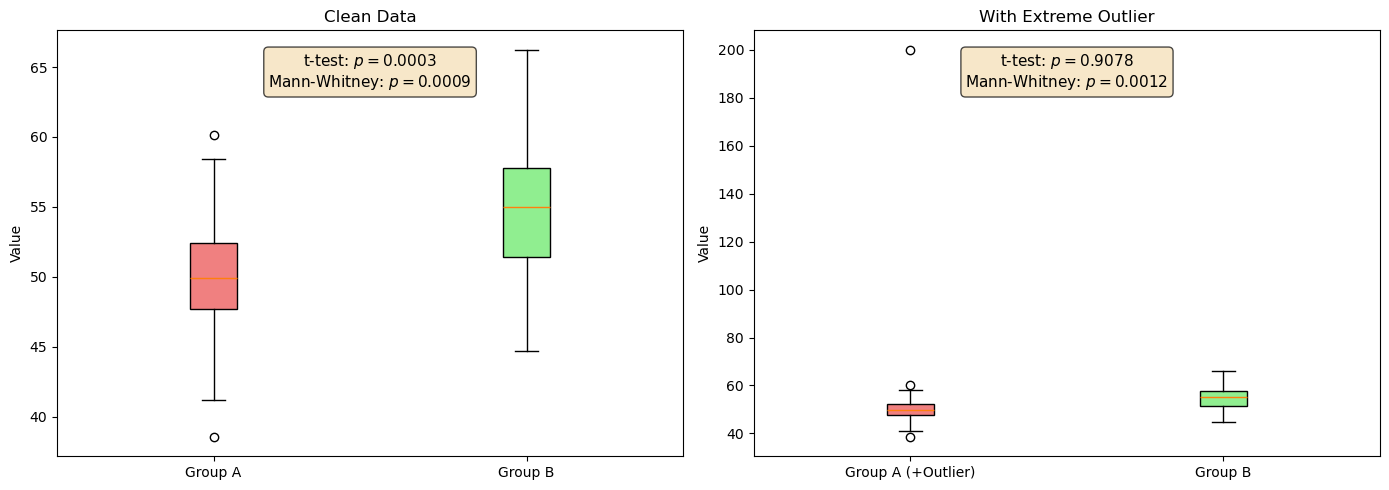

CLEAN DATA:
  t-test p-value:        0.0003
  Mann-Whitney p-value:  0.0009

WITH EXTREME OUTLIER:
  t-test p-value:        0.9078
  Mann-Whitney p-value:  0.0012

The t-test is heavily influenced by the outlier; Mann-Whitney remains stable.


In [9]:
np.random.seed(7)

# Clean data
clean_a = np.random.normal(50, 5, 30)
clean_b = np.random.normal(55, 5, 30)

# Add extreme outlier
outlier_a = clean_a.copy()
outlier_a[0] = 200

# Tests
t_clean, p_t_clean = stats.ttest_ind(clean_a, clean_b)
u_clean, p_u_clean = stats.mannwhitneyu(clean_a, clean_b, alternative='two-sided')

t_out, p_t_out = stats.ttest_ind(outlier_a, clean_b)
u_out, p_u_out = stats.mannwhitneyu(outlier_a, clean_b, alternative='two-sided')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Clean
ax1 = axes[0]
bp1 = ax1.boxplot([clean_a, clean_b], tick_labels=['Group A', 'Group B'],
                   patch_artist=True)
bp1['boxes'][0].set_facecolor('lightcoral')
bp1['boxes'][1].set_facecolor('lightgreen')
ax1.set_title('Clean Data')
ax1.set_ylabel('Value')

# With outlier
ax2 = axes[1]
bp2 = ax2.boxplot([outlier_a, clean_b], tick_labels=['Group A (+Outlier)', 'Group B'],
                   patch_artist=True)
bp2['boxes'][0].set_facecolor('lightcoral')
bp2['boxes'][1].set_facecolor('lightgreen')
ax2.set_title('With Extreme Outlier')
ax2.set_ylabel('Value')

# Add text with p-values
ax1.text(0.5, 0.95, rf't-test: $p = {p_t_clean:.4f}$' + '\n' +
         rf'Mann-Whitney: $p = {p_u_clean:.4f}$',
         transform=ax1.transAxes, fontsize=11, verticalalignment='top',
         horizontalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

ax2.text(0.5, 0.95, rf't-test: $p = {p_t_out:.4f}$' + '\n' +
         rf'Mann-Whitney: $p = {p_u_out:.4f}$',
         transform=ax2.transAxes, fontsize=11, verticalalignment='top',
         horizontalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

plt.tight_layout()
plt.savefig('robustness_outliers.png', dpi=150, bbox_inches='tight')
plt.show()

print("CLEAN DATA:")
print(f"  t-test p-value:        {p_t_clean:.4f}")
print(f"  Mann-Whitney p-value:  {p_u_clean:.4f}")
print("\nWITH EXTREME OUTLIER:")
print(f"  t-test p-value:        {p_t_out:.4f}")
print(f"  Mann-Whitney p-value:  {p_u_out:.4f}")
print("\nThe t-test is heavily influenced by the outlier; Mann-Whitney remains stable.")


## 9. Summary: Choosing the Right Non-Parametric Test

| Research Question | Parametric Test | Non-Parametric Alternative | Effect Size |
|-------------------|----------------|---------------------------|-------------|
| One sample vs. known value | One-sample t-test | Wilcoxon signed-rank (one-sample) | Rank-biserial r |
| Two independent groups | Independent t-test | Mann-Whitney U test | Rank-biserial r |
| Two paired groups | Paired t-test | Wilcoxon signed-rank test | Rank-biserial r |
| Three+ independent groups | One-way ANOVA | Kruskal-Wallis H test | Epsilon-squared |
| Post-hoc after KW | Tukey HSD | Dunn's test (with Bonferroni) | Rank-biserial r |
| Three+ paired groups | Repeated-measures ANOVA | Friedman test | Kendall's W |

### When to Choose Non-Parametric

1. **Data is ordinal** (e.g., Likert scales, rankings)
2. **Sample size is small** (n < 30 per group) and normality is uncertain
3. **Outliers are present** and you don't want to remove them
4. **Distribution is heavily skewed** or has heavy tails
5. **Variance is heterogeneous** across groups (Levene's test p < 0.05)

### Remember
- Non-parametric tests compare **distributions/location**, not specifically means
- They are **less powerful** than parametric tests when parametric assumptions are perfectly met
- They are **more powerful** when parametric assumptions are violated
- Always report **effect sizes** alongside p-values